# Notebook 04

# Extração de Características utilizando Composition of k-Spaced Amino Acid Pairs (CKSNAP)

No notebook anterior foi implementado o descritor Amino Acid Linking (AAL), responsável por representar cada sequência por meio da frequência dos pares consecutivos de aminoácidos.

Embora essa abordagem preserve parte da ordem dos resíduos, ela considera apenas aminoácidos adjacentes na sequência.

Entretanto, em proteínas e peptídeos, resíduos separados por alguns aminoácidos podem participar conjuntamente da formação da estrutura tridimensional e influenciar diretamente processos de reconhecimento molecular.

Para incorporar essa informação, neste notebook será implementado o descritor CKSNAP (Composition of k-Spaced Amino Acid Pairs), que contabiliza pares separados por diferentes distâncias ao longo da sequência.

## Objetivos

Ao final deste notebook será possível:

- compreender o descritor CKSNAP;

- implementar o algoritmo do zero;

- gerar descritores para diferentes valores de k;

- analisar o impacto do aumento da distância entre resíduos;

- comparar CKSNAP com AAC e AAL.

## Por que o AAL ainda é limitado?

Considere a sequência

```
A G P L K T
```

O descritor AAL considera apenas

```
AG

GP

PL

LK

KT
```

Entretanto,

os pares

```
AP

GL

PK

LT
```

também carregam informação importante.

Da mesma forma,

```
AL

GK

PT
```

podem participar da formação de estruturas secundárias.

O descritor CKSNAP captura exatamente esse tipo de relação.

## Composition of k-Spaced Amino Acid Pairs

Para cada valor de k, o algoritmo contabiliza pares de aminoácidos separados exatamente por k resíduos.

Quando

k=0

obtém-se exatamente os pares consecutivos utilizados pelo descritor AAL.

Quando

k=1

há um aminoácido entre os dois resíduos.

Quando

k=2

existem dois resíduos intermediários.

...

Neste trabalho será utilizado

```
k = 0,1,2,3,4,5
```

como definido pelo framework SAGAPEP.

Considere uma sequência contendo N aminoácidos.

Para um determinado valor de k,

existem

\[
N-k-1
\]

pares possíveis.

A frequência relativa do par

ij

é dada por

\[
CKSNAP_{ij}^{(k)}
=
\frac{n_{ij}^{(k)}}
{N-k-1}
\]

onde

- \(n_{ij}^{(k)}\) representa o número de ocorrências do par separado por distância \(k\);

- \(N-k-1\) representa o número total de pares possíveis para essa distância.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [2]:
df = pd.read_csv("../data/raw/sagapep.csv")
df.head(10)

,peptide_fasta_sequence,best_docking_score
0,RFGYGYGPY,-230.308
1,PAAAPPTLPPYFMKGSIIQLANGELKKV,-227.293
2,SIPPCPQTWRSLWIGYSFLMHTG,-224.630
3,RIGRFGYGYGPY,-218.979
4,PGPRYQPFRLT,-218.227
5,WAFTPLHEAAQKGRTQLCALLL,-214.970
6,PGPSSPYIPSPGGAMSPSYSPTSPAYEP,-210.899
7,SRGPPPRATRLPPPGPLCSSFSTP,-210.009
8,GRFGYGYGPY,-209.840
9,PRGPAGPSGPAGKDGRTGHPGTVGPAGIRGPQGHQGPAGPPGPPGP,-209.592


In [3]:
from itertools import product

AA = [
"A","C","D","E","F",
"G","H","I","K","L",
"M","N","P","Q","R",
"S","T","V","W","Y"
]

pairs = [
    a+b
    for a,b in product(AA,AA)
]

In [ ]:
# Implementação do algoritmo
from collections import Counter

def cksnap(sequence, k):
    seq = sequence.upper()
    links = []
    for i in range(len(seq)-k-1):
        links.append(
            seq[i] +
            seq[i+k+1]
        )

    total = len(links)
    counts = Counter(links)
    vector = {}

    for p in pairs:
        if total == 0:
            vector[p]=0
        else:
            vector[p]=counts.get(p,0)/total
    return vector

In [5]:
cksnap("AGPLKT",0)

{'AA': 0.0,
 'AC': 0.0,
 'AD': 0.0,
 'AE': 0.0,
 'AF': 0.0,
 'AG': 0.2,
 'AH': 0.0,
 'AI': 0.0,
 'AK': 0.0,
 'AL': 0.0,
 'AM': 0.0,
 'AN': 0.0,
 'AP': 0.0,
 'AQ': 0.0,
 'AR': 0.0,
 'AS': 0.0,
 'AT': 0.0,
 'AV': 0.0,
 'AW': 0.0,
 'AY': 0.0,
 'CA': 0.0,
 'CC': 0.0,
 'CD': 0.0,
 'CE': 0.0,
 'CF': 0.0,
 'CG': 0.0,
 'CH': 0.0,
 'CI': 0.0,
 'CK': 0.0,
 'CL': 0.0,
 'CM': 0.0,
 'CN': 0.0,
 'CP': 0.0,
 'CQ': 0.0,
 'CR': 0.0,
 'CS': 0.0,
 'CT': 0.0,
 'CV': 0.0,
 'CW': 0.0,
 'CY': 0.0,
 'DA': 0.0,
 'DC': 0.0,
 'DD': 0.0,
 'DE': 0.0,
 'DF': 0.0,
 'DG': 0.0,
 'DH': 0.0,
 'DI': 0.0,
 'DK': 0.0,
 'DL': 0.0,
 'DM': 0.0,
 'DN': 0.0,
 'DP': 0.0,
 'DQ': 0.0,
 'DR': 0.0,
 'DS': 0.0,
 'DT': 0.0,
 'DV': 0.0,
 'DW': 0.0,
 'DY': 0.0,
 'EA': 0.0,
 'EC': 0.0,
 'ED': 0.0,
 'EE': 0.0,
 'EF': 0.0,
 'EG': 0.0,
 'EH': 0.0,
 'EI': 0.0,
 'EK': 0.0,
 'EL': 0.0,
 'EM': 0.0,
 'EN': 0.0,
 'EP': 0.0,
 'EQ': 0.0,
 'ER': 0.0,
 'ES': 0.0,
 'ET': 0.0,
 'EV': 0.0,
 'EW': 0.0,
 'EY': 0.0,
 'FA': 0.0,
 'FC': 0.0,
 'FD': 0.0,
 'FE

In [7]:
sum(
    cksnap(
        "AGPLKT",
        2
    ).values()
)

1.0

In [8]:
# Construindo o Dataset
dfs = []

for k in range(6):
    temp = (
        df["peptide_fasta_sequence"]
        .apply(
            lambda x: cksnap(x,k)
        )
        .apply(pd.Series)
    )

    temp.columns = [
        f"{c}_k{k}"
        for c in temp.columns
    ]

    dfs.append(temp)

In [11]:
cksnap_df = pd.concat(
    dfs,
    axis=1
)

cksnap_df[
    "best_docking_score"
] = df[
    "best_docking_score"
]

cksnap_df.head()

,AA_k0,AC_k0,AD_k0,AE_k0,AF_k0,AG_k0,AH_k0,AI_k0,AK_k0,AL_k0,...,YN_k5,YP_k5,YQ_k5,YR_k5,YS_k5,YT_k5,YV_k5,YW_k5,YY_k5,best_docking_score
0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,-230.308
1,0.074074,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,-227.293
2,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.058824,0.0,0.0,0.0,-224.630
3,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,-218.979
4,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.200000,0.0,0.0,0.0,-218.227


## Validação da matriz CKSNAP

Antes de iniciar a análise estatística, é necessário verificar se os descritores foram calculados corretamente.

Para cada valor de \(k\), a soma das frequências relativas dos 400 pares possíveis deve ser igual a 1. Essa propriedade garante que a implementação está consistente e que todas as sequências foram corretamente representadas.

In [12]:
# ============================================================
# Validação da matriz CKSNAP
# ============================================================

for k in range(6):

    cols = [c for c in cksnap_df.columns if c.endswith(f"_k{k}")]

    soma = cksnap_df[cols].sum(axis=1)

    print(f"\nk = {k}")
    print(f"mínimo : {soma.min():.6f}")
    print(f"máximo : {soma.max():.6f}")

    assert np.allclose(soma,1)

print("\n✓ Todas as representações foram validadas.")


k = 0
mínimo : 1.000000
máximo : 1.000000

k = 1
mínimo : 1.000000
máximo : 1.000000

k = 2
mínimo : 1.000000
máximo : 1.000000

k = 3
mínimo : 1.000000
máximo : 1.000000

k = 4
mínimo : 1.000000
máximo : 1.000000

k = 5
mínimo : 1.000000
máximo : 1.000000

✓ Todas as representações foram validadas.


In [13]:
# Estatística Descritiva
# Como existem 2400 atributos, faremos uma análise resumida.
estatisticas = {}

for k in range(6):
    cols = [c for c in cksnap_df.columns if c.endswith(f"_k{k}")]
    estatisticas[k] = {
        "Variância média":
            cksnap_df[cols].var().mean(),
        "Maior variância":
            cksnap_df[cols].var().max(),
        "Menor variância":
            cksnap_df[cols].var().min()
    }

estatisticas = pd.DataFrame(estatisticas).T
estatisticas

,Variância média,Maior variância,Menor variância
0,0.000270,0.028491,0.0
1,0.000276,0.024826,0.0
2,0.000308,0.024150,0.0
3,0.000327,0.020454,0.0
4,0.000366,0.016827,0.0
5,0.000446,0.016420,0.0


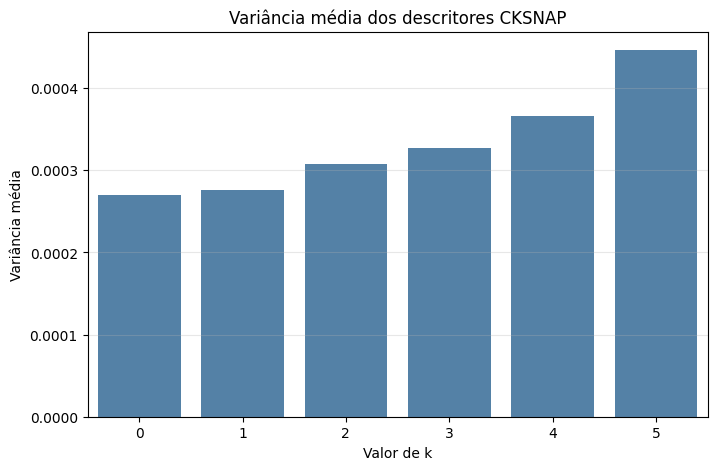

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=estatisticas.index,
    y=estatisticas["Variância média"],
    color="steelblue"
)

plt.title("Variância média dos descritores CKSNAP")

plt.xlabel("Valor de k")

plt.ylabel("Variância média")

plt.grid(axis="y", alpha=0.3)

plt.show()

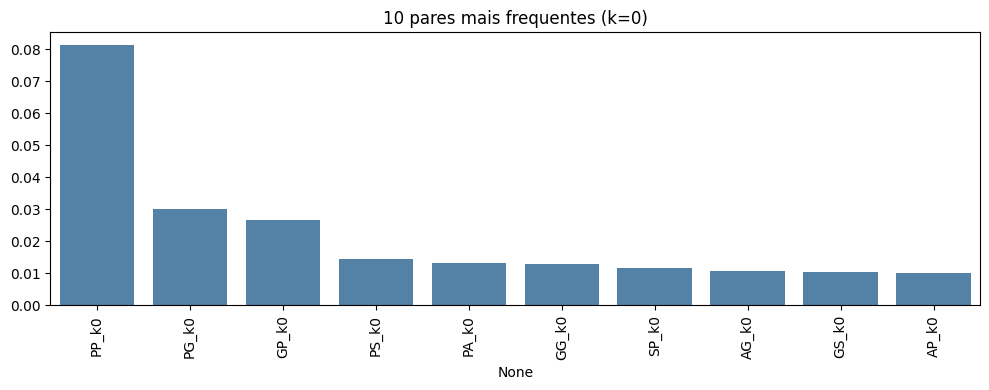

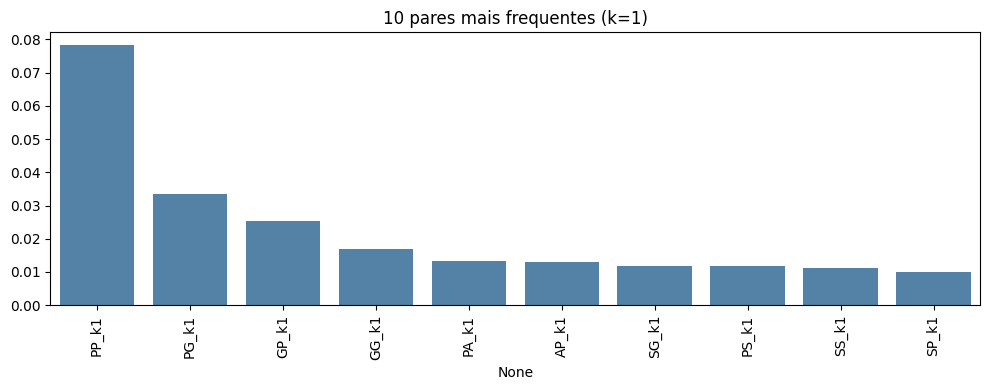

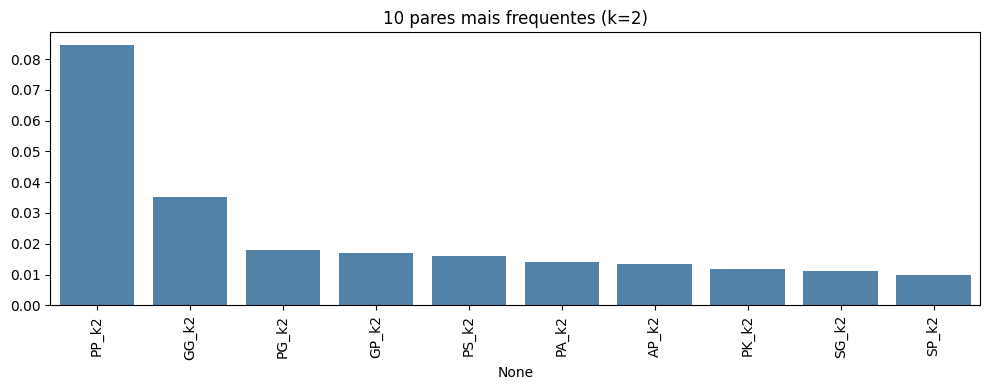

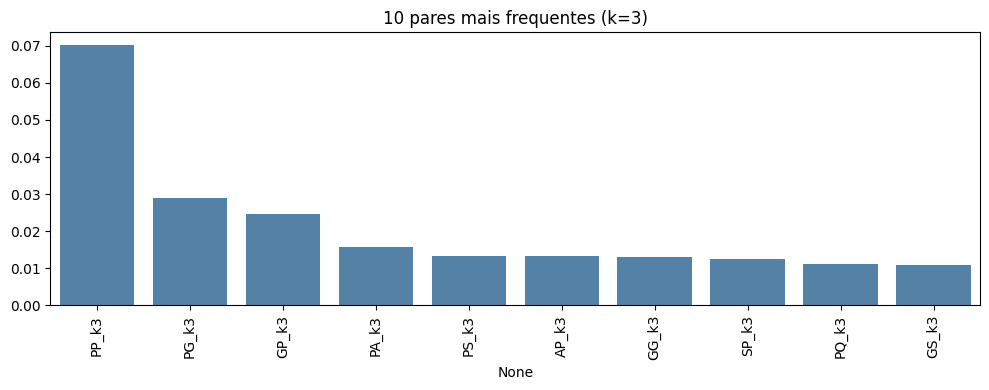

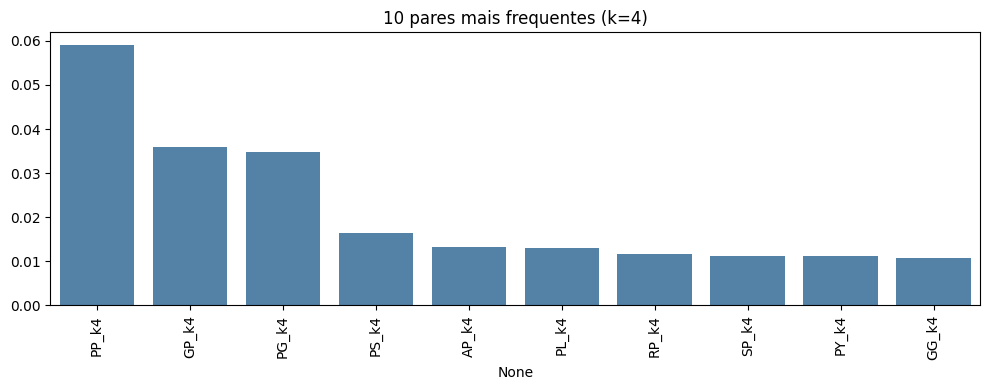

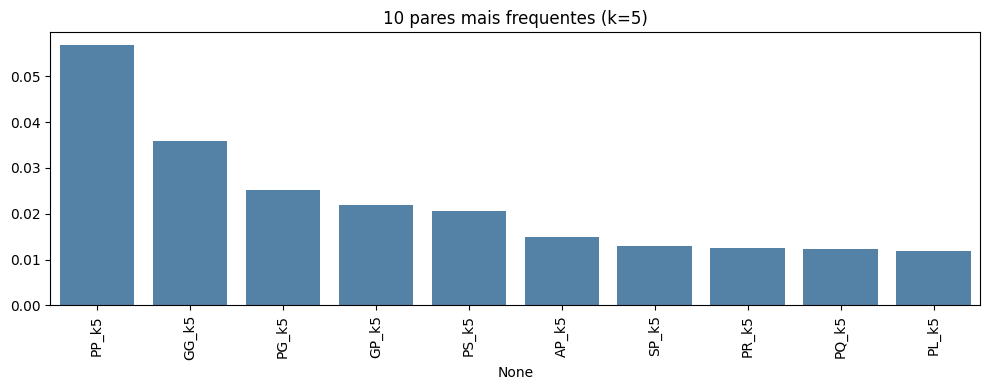

In [16]:
# Frequência Média dos Pares
for k in range(6):
    cols = [c for c in cksnap_df.columns if c.endswith(f"_k{k}")]
    media = (
        cksnap_df[cols]
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(10,4))
    
    sns.barplot(
        x=media.index,
        y=media.values,
        color="steelblue"
    )

    plt.xticks(rotation=90)
    plt.title(f"10 pares mais frequentes (k={k})")
    plt.tight_layout()
    plt.show()

C:\Users\amaur\AppData\Local\Temp\ipykernel_35788\2021857784.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\amaur\AppData\Local\Temp\ipykernel_35788\2021857784.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\amaur\AppData\Local\Temp\ipykernel_35788\2021857784.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\amaur\AppData\Local\Temp\ipykernel_35788\2021857784.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotat

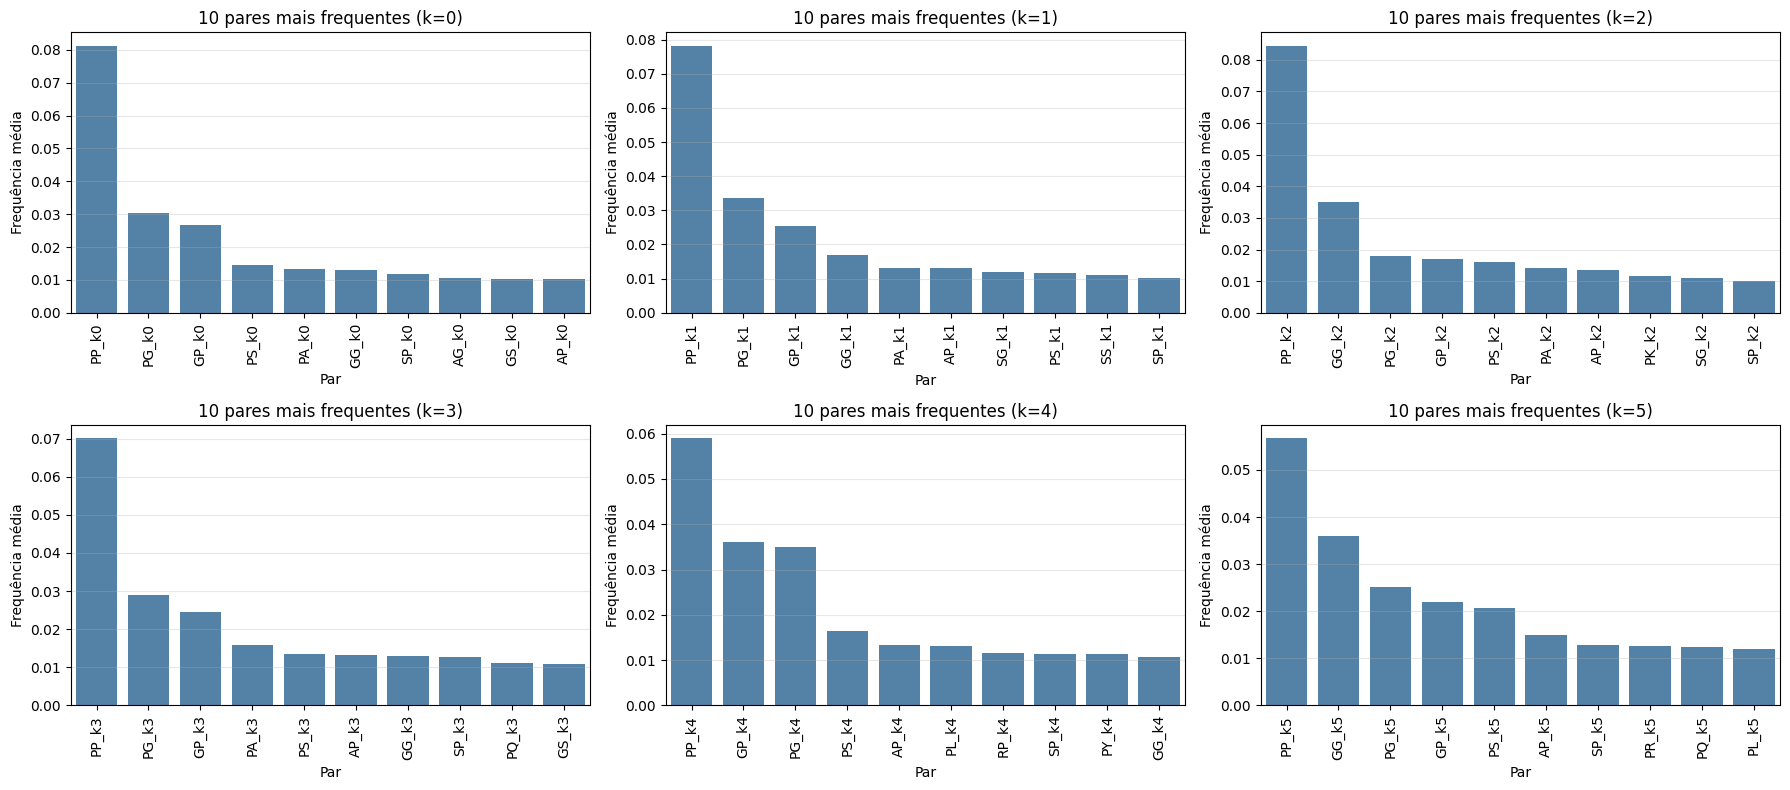

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Criar figura com 6 subplots (2 linhas x 3 colunas)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for k, ax in enumerate(axes.flat):
    cols = [c for c in cksnap_df.columns if c.endswith(f"_k{k}")]
    media = (
        cksnap_df[cols]
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )
    
    sns.barplot(
        x=media.index,
        y=media.values,
        color="steelblue",
        ax=ax
    )
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_title(f"10 pares mais frequentes (k={k})")
    ax.set_xlabel("Par")
    ax.set_ylabel("Frequência média")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


In [17]:
# PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_resultados = []
for k in range(6):
    cols = [c for c in cksnap_df.columns if c.endswith(f"_k{k}")]
    X = StandardScaler().fit_transform(
        cksnap_df[cols]
    )

    pca = PCA(n_components=2)
    pca.fit(X)
    pca_resultados.append(
        pca.explained_variance_ratio_.sum()
    )
    
pca_resultados

[np.float64(0.02773670687203106),
 np.float64(0.028757096305458512),
 np.float64(0.028486576015251418),
 np.float64(0.025617045775408107),
 np.float64(0.02518935457877108),
 np.float64(0.02545096093513044)]

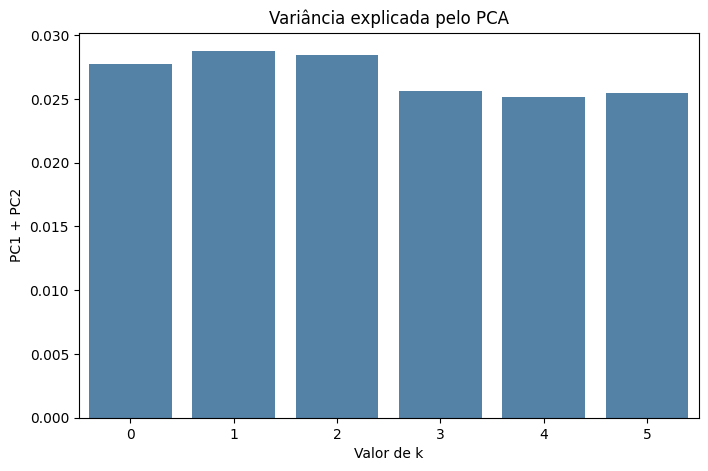

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=list(range(6)),
    y=pca_resultados,
    color="steelblue"
)

plt.title(
    "Variância explicada pelo PCA"
)

plt.xlabel("Valor de k")
plt.ylabel("PC1 + PC2")
plt.show()

In [19]:
# Informação Mútua
# Quais distâncias carregam mais informação.
from sklearn.feature_selection import mutual_info_regression

mi_resultados = []
for k in range(6):
    cols = [c for c in cksnap_df.columns if c.endswith(f"_k{k}")]
    mi = mutual_info_regression(
        cksnap_df[cols],
        cksnap_df["best_docking_score"],
        random_state=42
    )

    mi_resultados.append(
        np.mean(mi)
    )
mi_resultados

[np.float64(0.005499469599824923),
 np.float64(0.0047930715871517884),
 np.float64(0.004084858211994013),
 np.float64(0.004048887922652514),
 np.float64(0.003901599011827881),
 np.float64(0.0032205850836172665)]

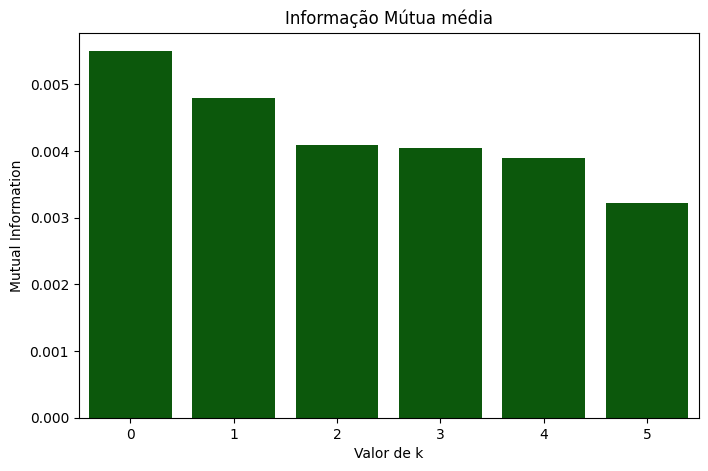

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=list(range(6)),
    y=mi_resultados,
    color="darkgreen"
)

plt.title(
    "Informação Mútua média"
)

plt.xlabel("Valor de k")
plt.ylabel("Mutual Information")
plt.show()

In [22]:
# Correlação
corr_resultados = []

for k in range(6):
    cols = [
        c for c in cksnap_df.columns
        if c.endswith(f"_k{k}")
    ]

    corr = (
        cksnap_df[cols]
        .corrwith(
            cksnap_df["best_docking_score"]
        )
        .abs()
    )

    corr_resultados.append(
        corr.mean()
    )

corr_resultados

c:\Users\amaur\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\amaur\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


[np.float64(0.05905219061492304),
 np.float64(0.06134251495360607),
 np.float64(0.05966927292279736),
 np.float64(0.05679241274522298),
 np.float64(0.05577106200433306),
 np.float64(0.05252035197085145)]

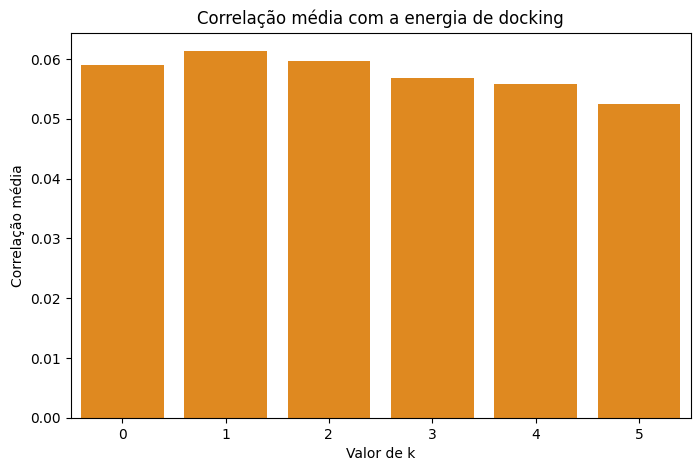

In [23]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=list(range(6)),
    y=corr_resultados,
    color="darkorange"
)

plt.title(
    "Correlação média com a energia de docking"
)

plt.xlabel("Valor de k")
plt.ylabel("Correlação média")
plt.show()

In [24]:
# Comparação entre os valores de k
comparacao = pd.DataFrame({
    "Variância média":
        estatisticas["Variância média"],
    "PCA":
        pca_resultados,
    "Informação Mútua":
        mi_resultados,
    "Correlação média":
        corr_resultados
})

comparacao

,Variância média,PCA,Informação Mútua,Correlação média
0,0.000270,0.027737,0.005499,0.059052
1,0.000276,0.028757,0.004793,0.061343
2,0.000308,0.028487,0.004085,0.059669
3,0.000327,0.025617,0.004049,0.056792
4,0.000366,0.025189,0.003902,0.055771
5,0.000446,0.025451,0.003221,0.052520


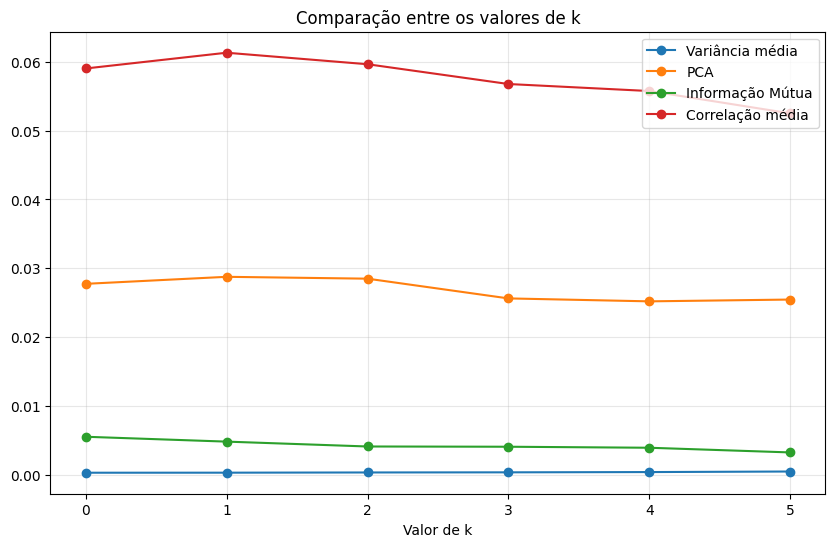

In [25]:
comparacao.plot(
    figsize=(10,6),
    marker="o"
)

plt.title(
    "Comparação entre os valores de k"
)

plt.xlabel("Valor de k")
plt.grid(alpha=0.3)
plt.show()

In [26]:
X_cksnap = StandardScaler().fit_transform(
    cksnap_df.drop(columns="best_docking_score")
)

pca_cksnap = PCA(n_components=2)
pca_cksnap.fit(X_cksnap)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [27]:
# Salvar o objeto PCA
import pickle

with open("../data/processed/pca_cksnap.pkl", "wb") as f:
    pickle.dump(pca_cksnap, f)


In [28]:
# Comparação AAC × AAL × CKSNAP
with open("../data/processed/pca_aac.pkl", "rb") as f:
    pca_aac = pickle.load(f)

with open("../data/processed/pca_aal.pkl", "rb") as f:
    pca_aal = pickle.load(f)

aac_df = pd.read_csv("../data/processed/aac_features.csv")
aac_only = aac_df.drop(columns=["best_docking_score"])

aal_df = pd.read_csv("../data/processed/aal_features.csv")
aal_only = aal_df.drop(columns=["best_docking_score"])


comparacao_descritores = pd.DataFrame({
    "AAC": [
        aac_only.shape[1],
        aac_only.var().mean(),
        pca_aac.explained_variance_ratio_.sum()
    ],
    "AAL": [
        aal_only.shape[1],
        aal_only.var().mean(),
        pca_aal.explained_variance_ratio_.sum()
    ],
    "CKSNAP": [
        cksnap_df.drop(columns="best_docking_score").shape[1],
        cksnap_df.drop(columns="best_docking_score").var().mean(),
        pca_cksnap.explained_variance_ratio_.sum()
    ]
}, index=[
    "Número de atributos",
    "Variância média",
    "Variância explicada (PCA)"
])

comparacao_descritores

,AAC,AAL,CKSNAP
Número de atributos,20.000000,400.000000,2400.000000
Variância média,0.005424,0.000270,0.000332
Variância explicada (PCA),0.191438,0.027737,0.022264


In [29]:
# Salvando
cksnap_df.to_csv(
    "../data/processed/cksnap_features.csv",
    index=False
)

print("Dataset CKSNAP salvo.")

Dataset CKSNAP salvo.


## Conclusões

Neste notebook foi implementado o descritor **Composition of k-Spaced Amino Acid Pairs (CKSNAP)**, ampliando a representação das sequências por meio da consideração de pares de aminoácidos separados por diferentes distâncias ao longo da cadeia peptídica.

Diferentemente do AAL, que considera apenas resíduos consecutivos, o CKSNAP incorpora relações de vizinhança para múltiplos valores de \(k\), produzindo uma representação significativamente mais rica e de maior dimensionalidade.

As análises mostraram que diferentes valores de \(k\) apresentam comportamentos distintos quanto à variabilidade dos atributos, capacidade de explicação da variância (PCA), correlação com a energia de docking e Informação Mútua. Esses resultados sugerem que nem todas as distâncias contribuem igualmente para a caracterização das sequências.

A comparação entre AAC, AAL e CKSNAP evidencia uma evolução progressiva da capacidade representacional dos descritores, preparando o terreno para o próximo notebook, no qual será implementado o descritor **CKSAAGP**, responsável por representar pares de grupos de aminoácidos com base em suas propriedades físico-químicas.